In [42]:
import pandas as pd

df = pd.read_csv('/content/Unemployment in India.csv')

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [43]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (768, 7)

Column names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [44]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [45]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [46]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display the cleaned column names
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [47]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check the data type
print("Date column data type:", df['Date'].dtype)

# Display first 5 dates
print("\nFirst 5 dates:")
print(df['Date'].head())

Date column data type: datetime64[ns]

First 5 dates:
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [48]:
# Statistical summary of numerical columns
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [49]:
# Find the earliest and latest dates
print("Earliest Date:", df['Date'].min())
print("Latest Date:", df['Date'].max())

Earliest Date: 2019-05-31 00:00:00
Latest Date: 2020-06-30 00:00:00


In [50]:
# Remove rows where Region is missing
df = df.dropna(subset=['Region'])

# Check again
print("Missing Region values after cleaning:", df['Region'].isnull().sum())
print("New dataset shape:", df.shape)

Missing Region values after cleaning: 0
New dataset shape: (740, 7)


In [52]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicates again
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows after cleaning: 0
New dataset shape: (740, 7)


Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


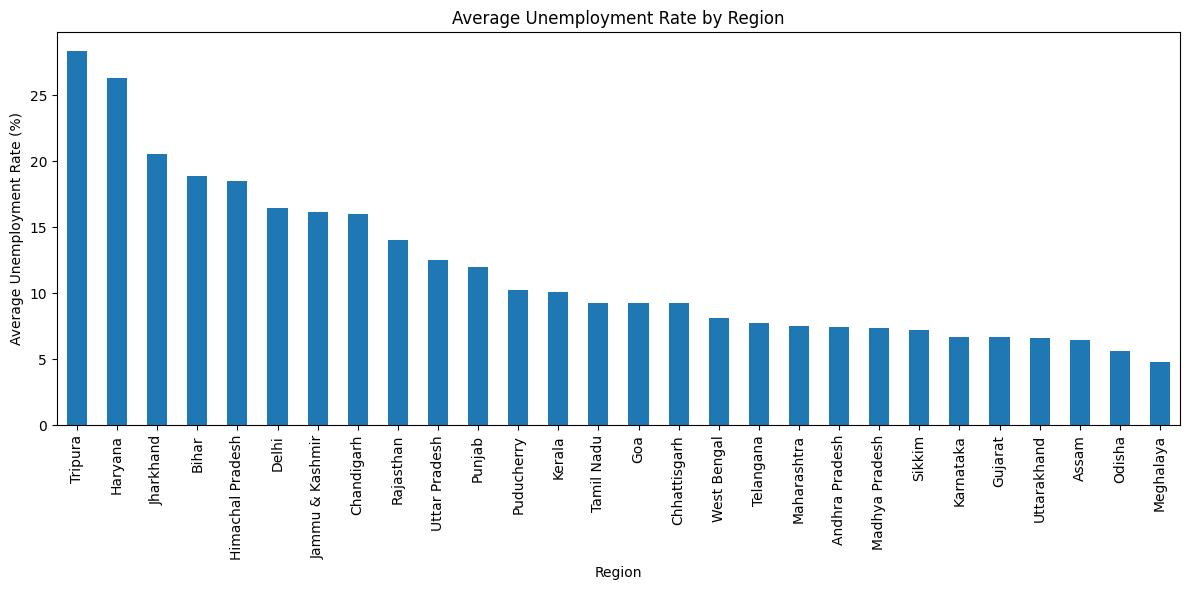

In [78]:
# Calculate average unemployment rate for each region
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Sort from highest to lowest
region_unemployment = region_unemployment.sort_values(ascending=False)

# Display the result
print("Average Unemployment Rate by Region:")
print(region_unemployment)

# Create bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Monthly Average Unemployment Rate:
Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


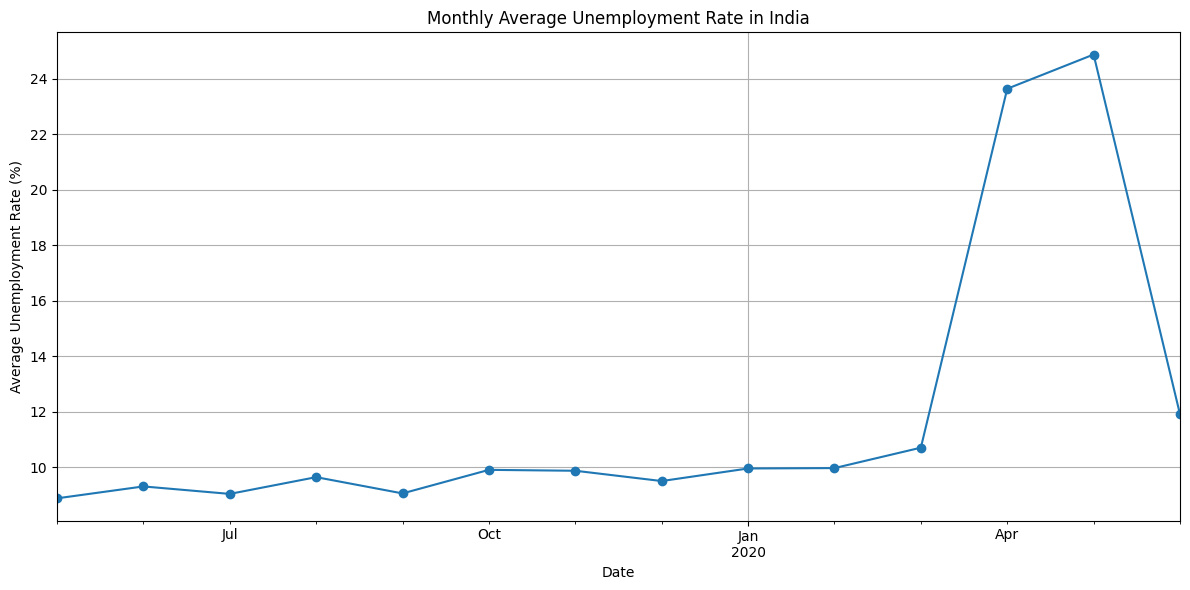

In [79]:
# Calculate average unemployment rate for each month
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

# Display monthly values
print("Monthly Average Unemployment Rate:")
print(monthly_unemployment)

# Create line chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
monthly_unemployment.plot(kind='line', marker='o')

plt.title('Monthly Average Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
# Create a period column based on the date
df['Period'] = df['Date'].apply(
    lambda x: 'Before COVID-19' if x < pd.Timestamp('2020-03-01')
    else 'During COVID-19'
)

# Calculate average unemployment rate for each period
covid_analysis = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:")
print(covid_analysis)

Average Unemployment Rate:
Period
Before COVID-19     9.509534
During COVID-19    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64


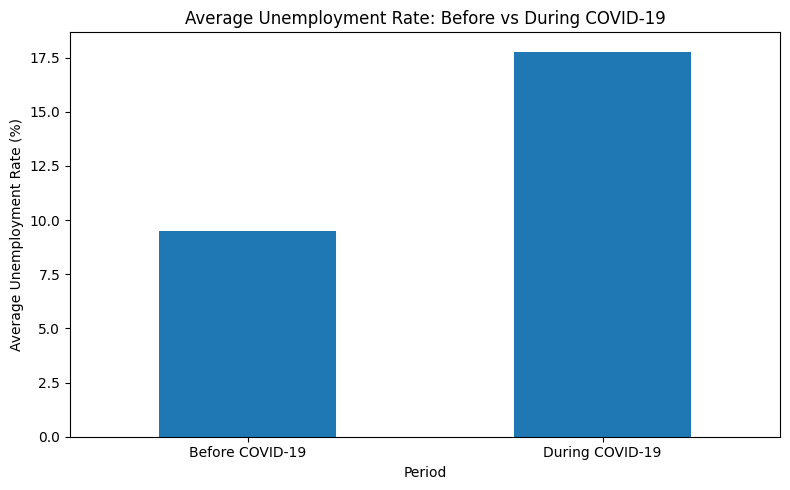

In [56]:
# Create a bar chart for COVID-19 comparison
plt.figure(figsize=(8, 5))

covid_analysis.plot(kind='bar')

plt.title('Average Unemployment Rate: Before vs During COVID-19')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [57]:
# Calculate average unemployment rate by area
area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


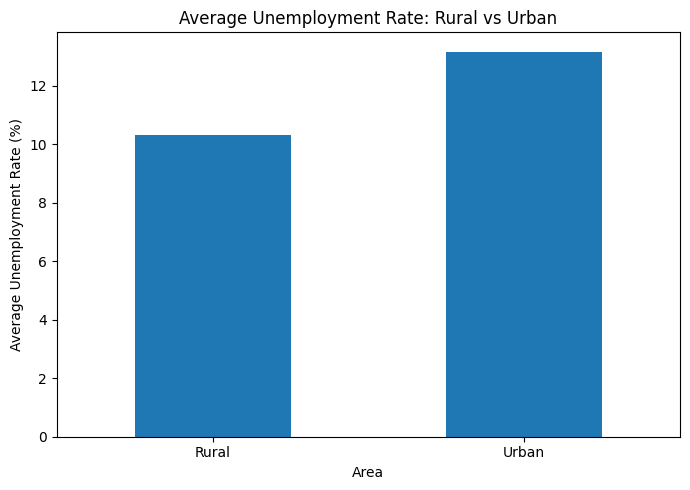

In [58]:
# Create bar chart
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [59]:
# Find the row with the highest unemployment rate
highest_unemployment = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmax()
]

print("Highest Unemployment Rate:")
print(highest_unemployment)

Highest Unemployment Rate:
Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
Period                                         During COVID-19
Name: 627, dtype: object


In [60]:
# Find the row with the lowest unemployment rate
lowest_unemployment = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmin()
]

print("Lowest Unemployment Rate:")
print(lowest_unemployment)

Lowest Unemployment Rate:
Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
Period                                         During COVID-19
Name: 25, dtype: object


In [61]:
# Select numerical columns
numerical_data = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

# Calculate correlation
correlation = numerical_data.corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


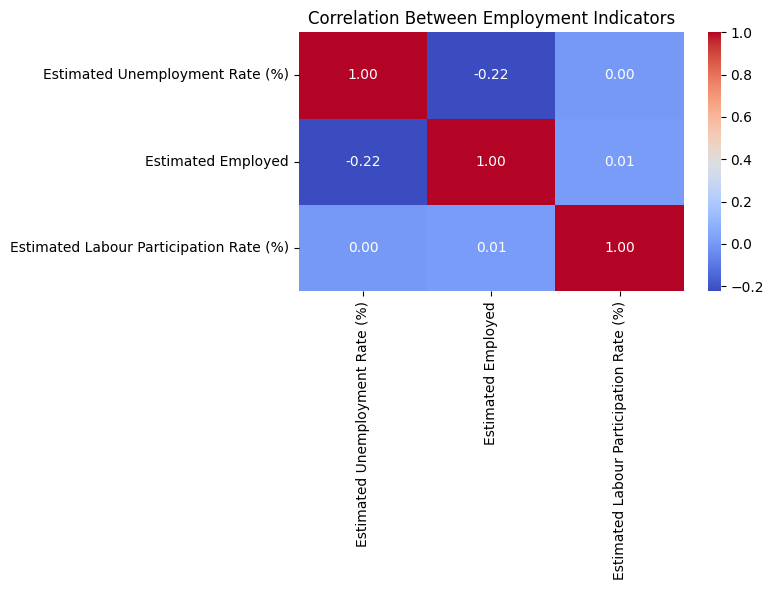

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')
plt.tight_layout()
plt.show()

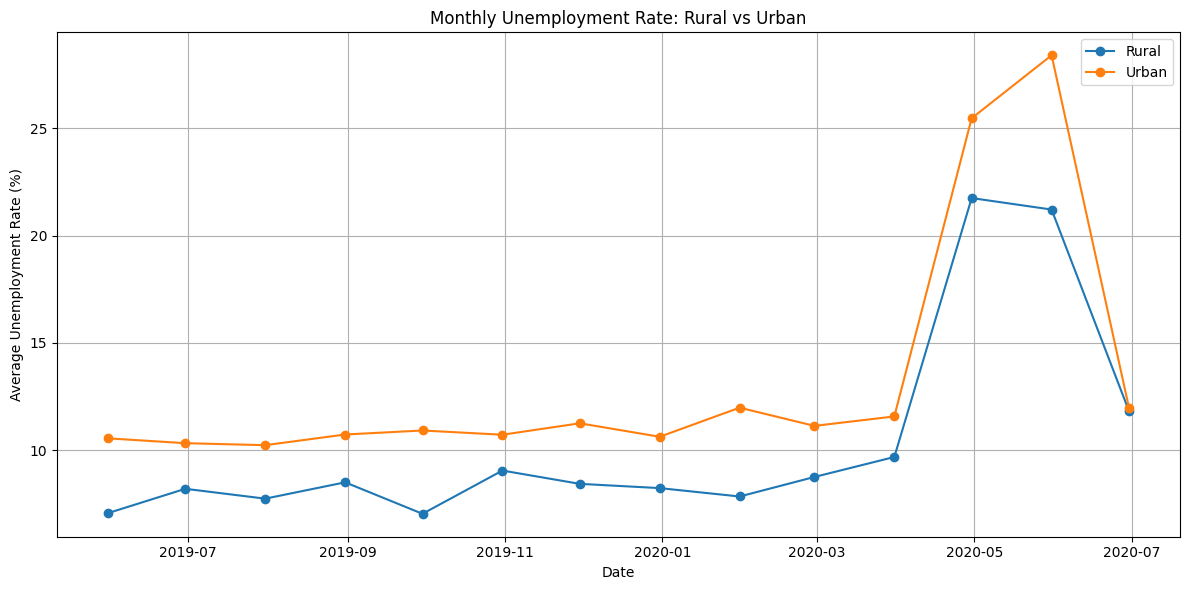

In [63]:
# Calculate monthly unemployment rate for each area
area_trend = df.groupby(['Date', 'Area'])[
    'Estimated Unemployment Rate (%)'
].mean().reset_index()

# Create line chart
plt.figure(figsize=(12, 6))

for area in area_trend['Area'].unique():
    area_data = area_trend[area_trend['Area'] == area]
    plt.plot(
        area_data['Date'],
        area_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=area
    )

plt.title('Monthly Unemployment Rate: Rural vs Urban')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Monthly Average Estimated Employment:
Date
2019-05-31    7.410148e+06
2019-06-30    7.358642e+06
2019-07-31    7.404425e+06
2019-08-31    7.539815e+06
2019-09-30    7.739464e+06
2019-10-31    7.298382e+06
2019-11-30    7.273661e+06
2019-12-31    7.377388e+06
2020-01-31    7.677344e+06
2020-02-29    7.603996e+06
2020-03-31    7.516581e+06
2020-04-30    5.283320e+06
2020-05-31    5.879363e+06
2020-06-30    7.387009e+06
Name: Estimated Employed, dtype: float64


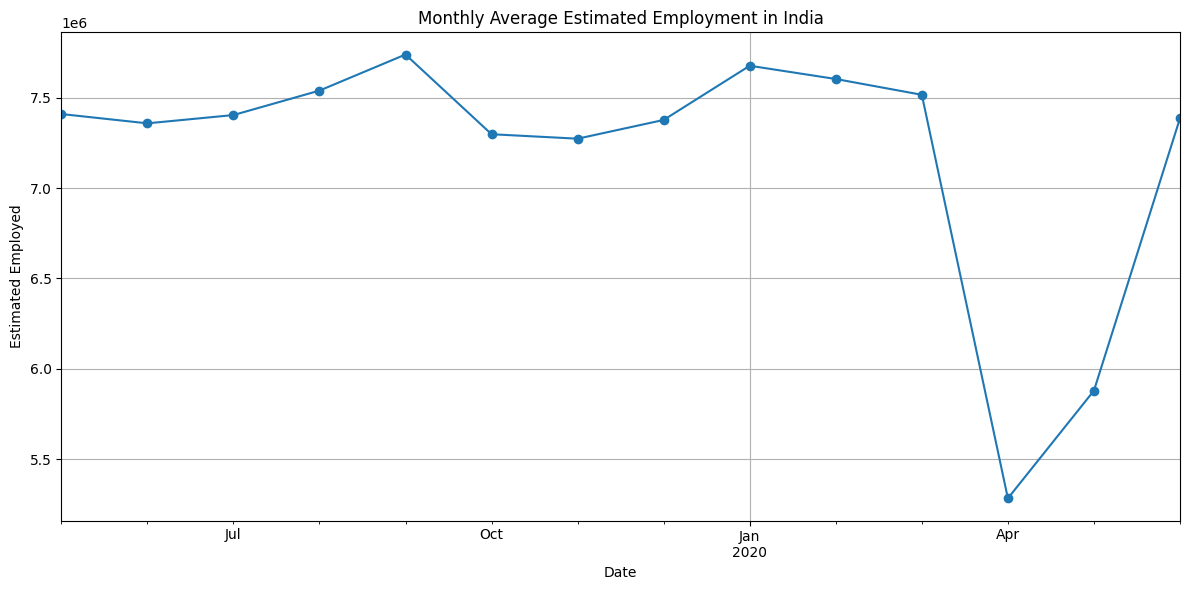

In [64]:
# Calculate average estimated employment for each month
monthly_employment = df.groupby('Date')['Estimated Employed'].mean()

# Display the values
print("Monthly Average Estimated Employment:")
print(monthly_employment)

# Create line chart
plt.figure(figsize=(12, 6))

monthly_employment.plot(kind='line', marker='o')

plt.title('Monthly Average Estimated Employment in India')
plt.xlabel('Date')
plt.ylabel('Estimated Employed')
plt.grid(True)

plt.tight_layout()
plt.show()

Monthly Average Labour Participation Rate:
Date
2019-05-31    43.902963
2019-06-30    43.750556
2019-07-31    43.706667
2019-08-31    43.646792
2019-09-30    44.301346
2019-10-31    44.001273
2019-11-30    44.110545
2019-12-31    43.667358
2020-01-31    44.051321
2020-02-29    43.723019
2020-03-31    43.084038
2020-04-30    35.141176
2020-05-31    38.496863
2020-06-30    40.548400
Name: Estimated Labour Participation Rate (%), dtype: float64


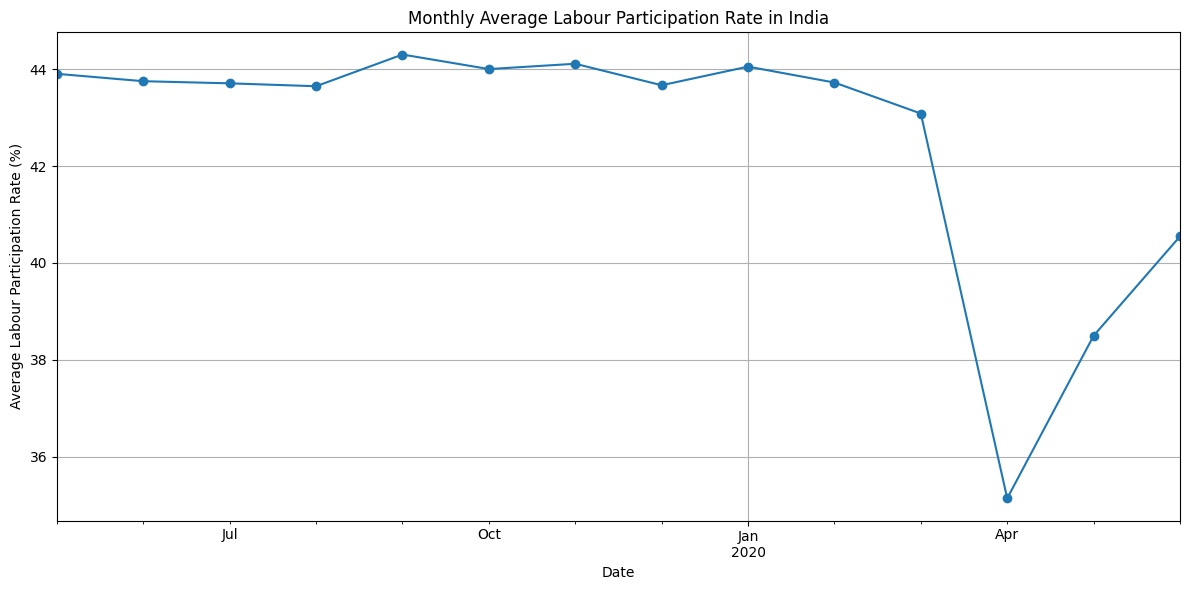

In [65]:
# Calculate average labour participation rate for each month
monthly_lpr = df.groupby('Date')['Estimated Labour Participation Rate (%)'].mean()

# Display the values
print("Monthly Average Labour Participation Rate:")
print(monthly_lpr)

# Create line chart
plt.figure(figsize=(12, 6))

monthly_lpr.plot(kind='line', marker='o')

plt.title('Monthly Average Labour Participation Rate in India')
plt.xlabel('Date')
plt.ylabel('Average Labour Participation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

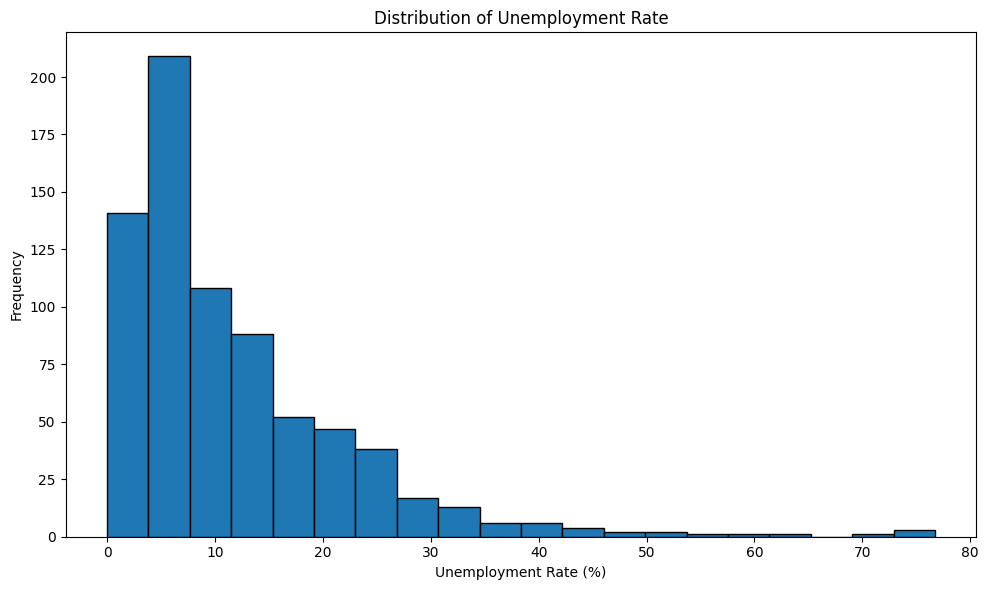

In [66]:
# Plot distribution of unemployment rate
plt.figure(figsize=(10, 6))

plt.hist(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [67]:
# Check the frequency values
print("Frequency values:")
print(df['Frequency'].value_counts())

# Calculate average unemployment rate by frequency
frequency_unemployment = df.groupby('Frequency')['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate by Frequency:")
print(frequency_unemployment)

Frequency values:
Frequency
Monthly     381
 Monthly    359
Name: count, dtype: int64

Average Unemployment Rate by Frequency:
Frequency
 Monthly    10.324791
Monthly     13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


In [68]:
# Calculate average unemployment rate by region
top_regions = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Regions with Highest Average Unemployment Rate:")
print(top_regions)

Top 10 Regions with Highest Average Unemployment Rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


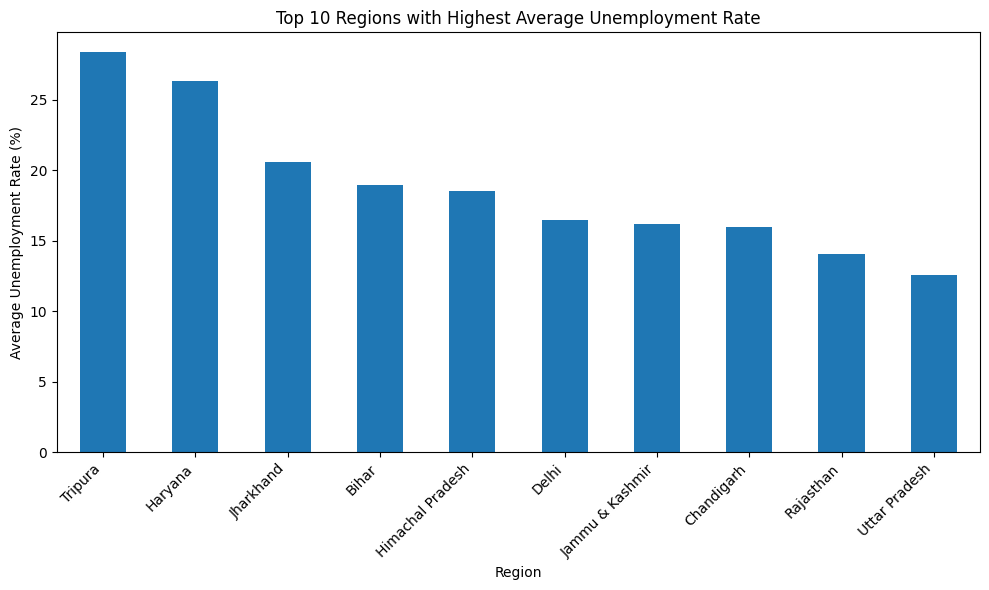

In [69]:
plt.figure(figsize=(10, 6))

top_regions.plot(kind='bar')

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [70]:
# Calculate average unemployment rate by region
lowest_regions = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

print("Top 10 Regions with Lowest Average Unemployment Rate:")
print(lowest_regions)

Top 10 Regions with Lowest Average Unemployment Rate:
Region
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Estimated Unemployment Rate (%), dtype: float64


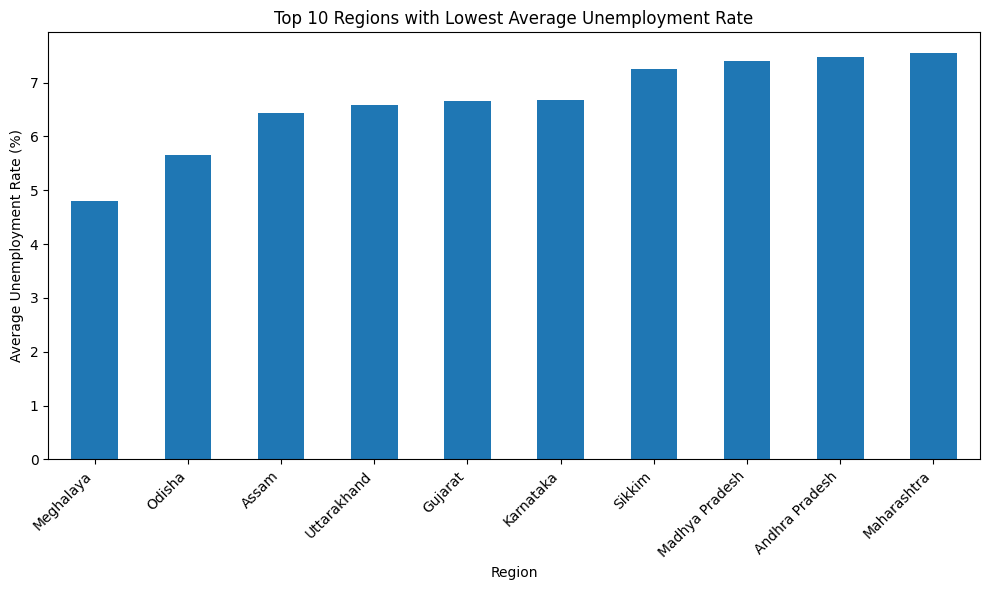

In [71]:
plt.figure(figsize=(10, 6))

lowest_regions.plot(kind='bar')

plt.title('Top 10 Regions with Lowest Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [72]:
# Calculate average unemployment rate by Region and Area
region_area = df.groupby(
    ['Region', 'Area']
)['Estimated Unemployment Rate (%)'].mean().reset_index()

print("Average Unemployment Rate by Region and Area:")
print(region_area)

Average Unemployment Rate by Region and Area:
              Region   Area  Estimated Unemployment Rate (%)
0     Andhra Pradesh  Rural                         5.526429
1     Andhra Pradesh  Urban                         9.427857
2              Assam  Rural                         4.490833
3              Assam  Urban                         8.088571
4              Bihar  Rural                        16.770000
5              Bihar  Urban                        21.066429
6         Chandigarh  Urban                        15.991667
7       Chhattisgarh  Rural                         6.628571
8       Chhattisgarh  Urban                        11.852143
9              Delhi  Rural                        15.258571
10             Delhi  Urban                        17.732143
11               Goa  Rural                         8.390000
12               Goa  Urban                        10.158333
13           Gujarat  Rural                         5.917143
14           Gujarat  Urban            

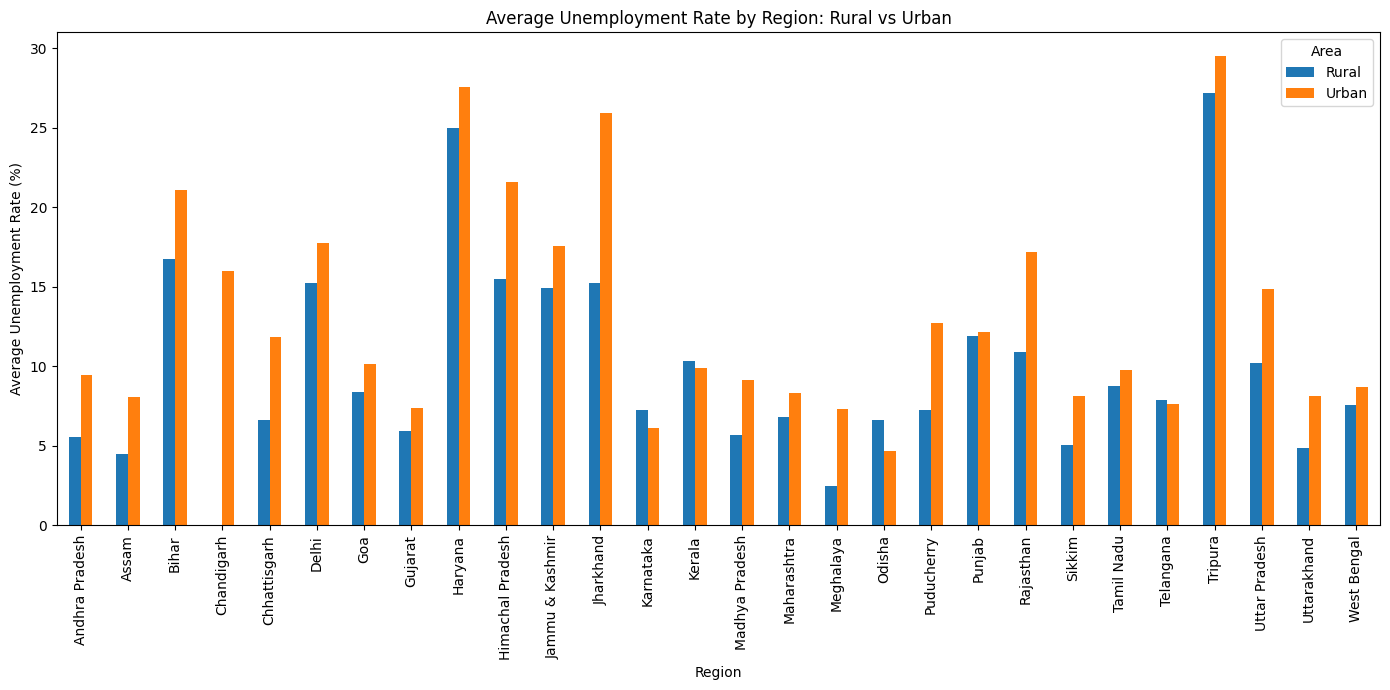

In [73]:
# Pivot the data for visualization
region_area_pivot = region_area.pivot(
    index='Region',
    columns='Area',
    values='Estimated Unemployment Rate (%)'
)

# Create grouped bar chart
region_area_pivot.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Average Unemployment Rate by Region: Rural vs Urban')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.legend(title='Area')

plt.tight_layout()
plt.show()

In [74]:
# Find the month with the highest average unemployment rate
peak_month = monthly_unemployment.idxmax()
peak_rate = monthly_unemployment.max()

print("Peak Unemployment Period:", peak_month)
print("Highest Average Unemployment Rate:", round(peak_rate, 2), "%")

Peak Unemployment Period: 2020-05-31 00:00:00
Highest Average Unemployment Rate: 24.88 %


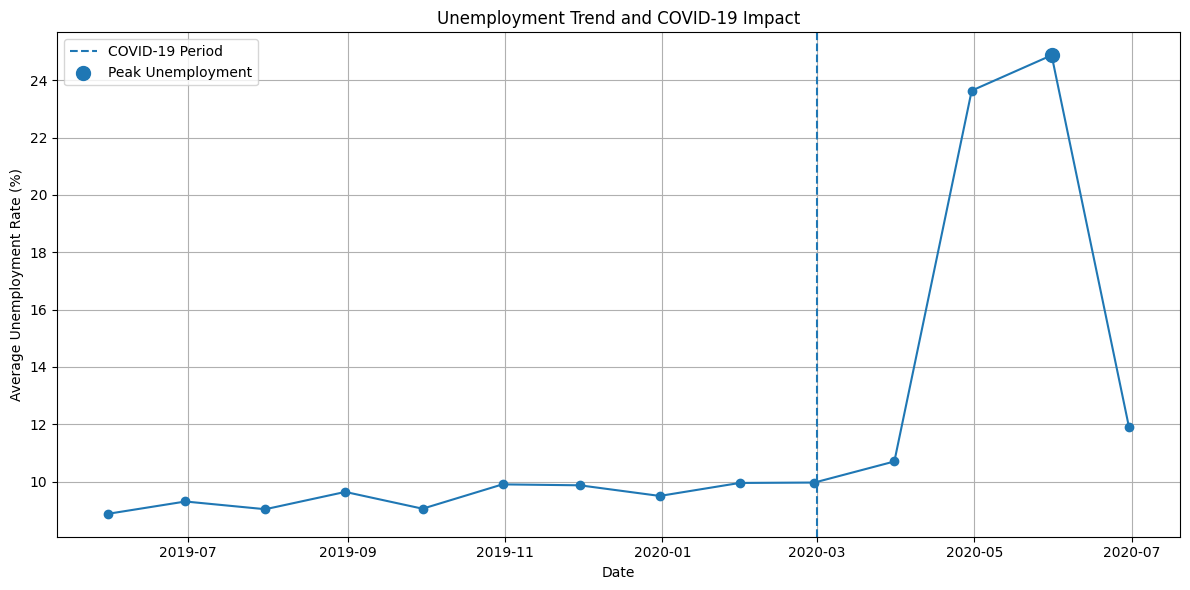

In [75]:
# Plot unemployment trend and highlight COVID-19 peak

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

# Mark the beginning of COVID-19 period
plt.axvline(
    pd.Timestamp('2020-03-01'),
    linestyle='--',
    label='COVID-19 Period'
)

# Mark the peak unemployment
plt.scatter(
    peak_month,
    peak_rate,
    s=100,
    label='Peak Unemployment'
)

plt.title('Unemployment Trend and COVID-19 Impact')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [76]:
# Calculate overall statistics

overall_unemployment = df['Estimated Unemployment Rate (%)'].mean()
overall_employment = df['Estimated Employed'].mean()
overall_lpr = df['Estimated Labour Participation Rate (%)'].mean()

print("Overall Average Unemployment Rate:",
      round(overall_unemployment, 2), "%")

print("Overall Average Estimated Employment:",
      round(overall_employment, 2))

print("Overall Average Labour Participation Rate:",
      round(overall_lpr, 2), "%")

Overall Average Unemployment Rate: 11.79 %
Overall Average Estimated Employment: 7204460.03
Overall Average Labour Participation Rate: 42.63 %


In [77]:
# Get important values for final observations

highest_region = region_unemployment.index[0]
highest_region_rate = region_unemployment.iloc[0]

lowest_region = region_unemployment.index[-1]
lowest_region_rate = region_unemployment.iloc[-1]

highest_area = area_unemployment.idxmax()
highest_area_rate = area_unemployment.max()

lowest_area = area_unemployment.idxmin()
lowest_area_rate = area_unemployment.min()

print("Highest Average Unemployment Region:",
      highest_region, "-", round(highest_region_rate, 2), "%")

print("Lowest Average Unemployment Region:",
      lowest_region, "-", round(lowest_region_rate, 2), "%")

print("Higher Unemployment Area:",
      highest_area, "-", round(highest_area_rate, 2), "%")

print("Lower Unemployment Area:",
      lowest_area, "-", round(lowest_area_rate, 2), "%")

print("COVID-19 Peak Month:",
      peak_month)

print("COVID-19 Peak Unemployment Rate:",
      round(peak_rate, 2), "%")

Highest Average Unemployment Region: Tripura - 28.35 %
Lowest Average Unemployment Region: Meghalaya - 4.8 %
Higher Unemployment Area: Urban - 13.17 %
Lower Unemployment Area: Rural - 10.32 %
COVID-19 Peak Month: 2020-05-31 00:00:00
COVID-19 Peak Unemployment Rate: 24.88 %


Observations

Tripura recorded the highest average unemployment rate at 28.35%, while Meghalaya recorded the lowest at 4.80%.
The average unemployment rate was higher in Urban areas (13.17%) than in Rural areas (10.32%).
The highest average unemployment rate was observed in May 2020, reaching approximately 24.88%, showing the impact of COVID-19.
The unemployment rate changed considerably across the months, with a noticeable increase during the COVID-19 period.
The analysis of employment and labour participation rates helped us understand changes in India's labour market.

Conclusion

The unemployment data was analyzed using Python to understand unemployment trends in India. The analysis showed differences in unemployment rates across regions and between urban and rural areas. Tripura had the highest average unemployment rate, while Meghalaya had the lowest. The unemployment rate reached its highest level in May 2020, showing the impact of the COVID-19 pandemic. This project demonstrates how data cleaning, exploratory data analysis, visualization, and statistical analysis can be used to understand real-world data.